 MOBILE PRICE CLASSIFICATION USING DECISION TREE

1. Install Libraries

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier

3. Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving mobile_price_dataset.csv to mobile_price_dataset.csv


4. Load Dataset

In [4]:
data = pd.read_csv("mobile_price_dataset.csv")

print("\nDataset Loaded Successfully")
print(data.head())


Dataset Loaded Successfully
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

5. Dataset Info

In [5]:
print("\nShape:", data.shape)
print("\nColumns:", data.columns)
print("\nMissing Values:\n", data.isnull().sum())


Shape: (891, 12)

Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


6. Correlation Heatmap

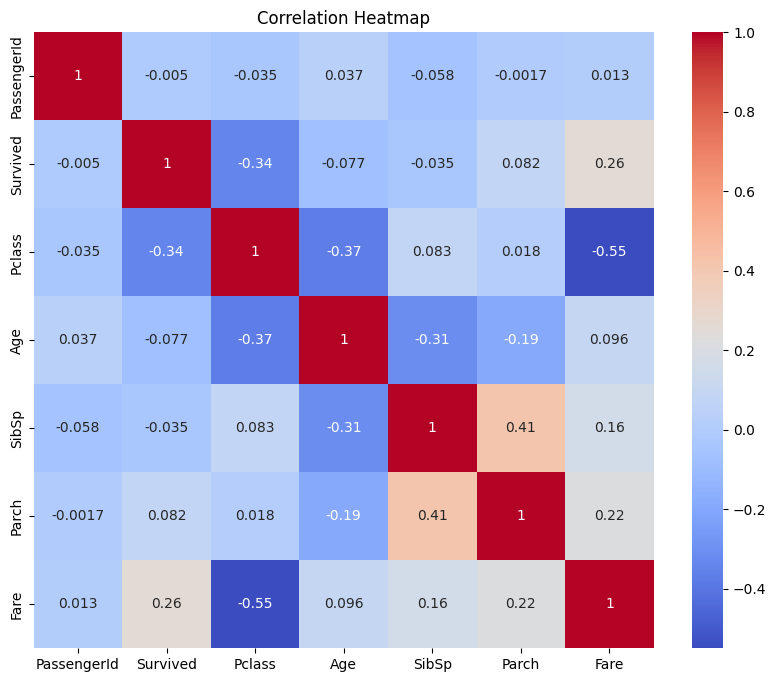

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

7. Feature & Target

In [15]:
X = data.drop(["PassengerId", "Survived", "Name", "Ticket", "Cabin"], axis=1)
X["Age"] = X["Age"].fillna(X["Age"].median())
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)
y = data["Survived"]

8. MODEL INITIALIZATION

In [13]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=6,
    random_state=42
)

9. FIRST SPLIT (80:20)

In [14]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train1, y_train1)
pred1 = model.predict(X_test1)

acc1 = accuracy_score(y_test1, pred1)

print("\n===== 80:20 SPLIT RESULTS =====")
print("Accuracy:", acc1)
print("\nClassification Report:\n", classification_report(y_test1, pred1))
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train1, y_train1)
pred1 = model.predict(X_test1)

acc1 = accuracy_score(y_test1, pred1)

print("\n===== 80:20 SPLIT RESULTS =====")
print("Accuracy:", acc1)
print("\nClassification Report:\n", classification_report(y_test1, pred1))



===== 80:20 SPLIT RESULTS =====
Accuracy: 0.8156424581005587

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85       105
           1       0.85      0.68      0.75        74

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179


===== 80:20 SPLIT RESULTS =====
Accuracy: 0.8156424581005587

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85       105
           1       0.85      0.68      0.75        74

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



10. SECOND SPLIT (70:30)


===== 70:30 SPLIT RESULTS =====
Accuracy: 0.7723880597014925

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.94      0.83       157
           1       0.86      0.54      0.66       111

    accuracy                           0.77       268
   macro avg       0.80      0.74      0.75       268
weighted avg       0.79      0.77      0.76       268



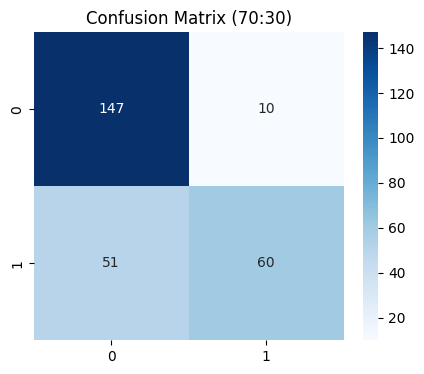

In [16]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model.fit(X_train2, y_train2)
pred2 = model.predict(X_test2)

acc2 = accuracy_score(y_test2, pred2)

print("\n===== 70:30 SPLIT RESULTS =====")
print("Accuracy:", acc2)
print("\nClassification Report:\n", classification_report(y_test2, pred2))

# Confusion Matrix
cm2 = confusion_matrix(y_test2, pred2)

plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (70:30)")
plt.show()

11. COMPARISON TABLE

In [17]:

results = pd.DataFrame({
    "Split": ["80:20", "70:30"],
    "Accuracy": [acc1, acc2]
})

print("\n===== FINAL COMPARISON TABLE =====")
print(results)



===== FINAL COMPARISON TABLE =====
   Split  Accuracy
0  80:20  0.815642
1  70:30  0.772388


12. Feature Importance




Feature Importance:
       Feature  Importance
5    Sex_male    0.415919
1         Age    0.204938
0      Pclass    0.168512
4        Fare    0.135203
2       SibSp    0.070960
3       Parch    0.004467
6  Embarked_Q    0.000000
7  Embarked_S    0.000000


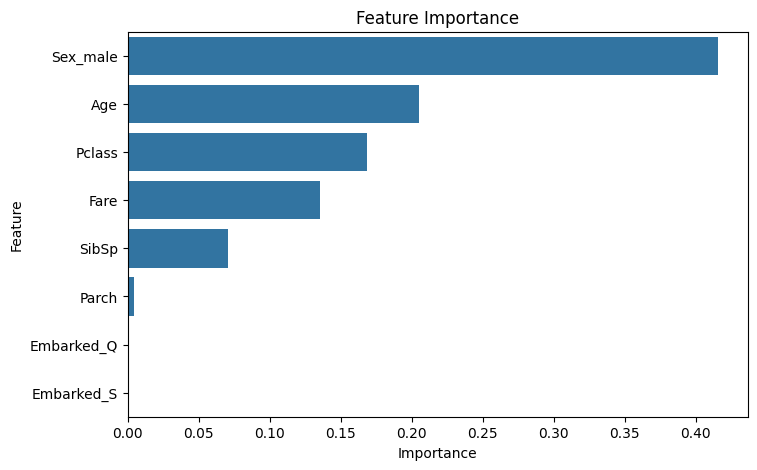

In [18]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:\n", importance)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title("Feature Importance")
plt.show()


13. Training vs Testing Accuracy

In [19]:
train_acc = model.score(X_train1, y_train1)
test_acc = model.score(X_test1, y_test1)

print("\nTraining Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)


Training Accuracy: 0.8412921348314607
Testing Accuracy: 0.776536312849162


14. Sample Prediction

In [20]:
sample = X_test1.iloc[0].values.reshape(1, -1)
print("\nSample Prediction:", model.predict(sample))



Sample Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


15. Final Output

In [21]:
print("\nDecision Tree Model Completed Successfully")
print("Comparison between different train-test splits completed")


Decision Tree Model Completed Successfully
Comparison between different train-test splits completed
